In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [124]:
path = '/Users/qianj/Library/Mobile Documents/com~apple~CloudDocs/AA_2024-2026 job/Erdos_Project'

In [125]:
pd.set_option('display.max_columns',None)

In [126]:
df_pushed_year = pd.read_csv(f'{path}/Modeling/common_NPI_pushed_year_df_with_pca_1_scaled_type_tot_risk_covid_3.csv').drop('Unnamed: 0',axis=1)
df_origin = pd.read_csv(f'{path}/Modeling/original_year_with_type_risk_tot_risk_pca_covid_3.csv').drop('Unnamed: 0', axis=1)

In [127]:
df_train = df_pushed_year[df_pushed_year['year']<=2020].copy()
df_val = df_origin[df_origin['year']==2020].copy() # use 2020 data predict for 2021, the df_val_df dataset is in original year
df_val['year']=2021
df_val['Is_Covid']=1
actual_total_y = sum(df_origin[df_origin['year']==2021]['Tot_Mdcr_Pymt_Amt'])
actual_y = df_origin[df_origin['year']==2021]['Tot_Mdcr_Pymt_Amt']
actual_total_y

109259516579.438

In [128]:
df_2021 = df_origin[df_origin['year']==2021].copy()
actual_total_2022 = sum(df_origin[df_origin['year']==2022]['Tot_Mdcr_Pymt_Amt'])
df_2021['year'] = 2022
df_2021['Is_Covid'] = 0
df_2022 = df_origin[df_origin['year']==2022].copy()
df_2022['year'] = 2023
actual_total_2023 = sum(df_origin[df_origin['year']==2023]['Tot_Mdcr_Pymt_Amt'])

In [7]:
set(df_val.columns.tolist())==set(df_train.columns.tolist())

True

In [8]:
df_cols = df_train.columns.tolist()
df_cols

['Rndrng_NPI',
 'Rndrng_Prvdr_Ent_Cd',
 'Rndrng_Prvdr_State_Abrvtn',
 'Rndrng_Prvdr_Type',
 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind',
 'Tot_HCPCS_Cds',
 'Tot_Benes',
 'Tot_Srvcs',
 'Bene_Avg_Age',
 'Bene_Avg_Risk_Scre',
 'pca_1_scaled',
 'Tot_Risk',
 'APP_Tot_Risk',
 'PrimaryCare_Tot_Risk',
 'MedicalSpecialtyOther_Tot_Risk',
 'LabPathology_Tot_Risk',
 'PharmacyNutrition_Tot_Risk',
 'state',
 'Tot_Mdcr_Pymt_Amt',
 'year',
 'Is_Covid']

# Null Model

In [9]:
MODEL_null_no_offset = smf.glm(
    formula="Tot_Mdcr_Pymt_Amt ~ 1",
    data=df_train,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    #offset=np.log(df_train["pca_1_scaled"]),
).fit()

In [10]:
MODEL_null_offset = smf.glm(
    formula="Tot_Mdcr_Pymt_Amt ~ 1",
    data=df_train,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    offset=np.log(df_train["pca_1_scaled"]),
).fit()

In [11]:
df_train.columns

Index(['Rndrng_NPI', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_State_Abrvtn',
       'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'Tot_HCPCS_Cds',
       'Tot_Benes', 'Tot_Srvcs', 'Bene_Avg_Age', 'Bene_Avg_Risk_Scre',
       'pca_1_scaled', 'Tot_Risk', 'APP_Tot_Risk', 'PrimaryCare_Tot_Risk',
       'MedicalSpecialtyOther_Tot_Risk', 'LabPathology_Tot_Risk',
       'PharmacyNutrition_Tot_Risk', 'state', 'Tot_Mdcr_Pymt_Amt', 'year',
       'Is_Covid'],
      dtype='object')

# Preprocessing Columns

In [39]:
label_cols = ['APP_Tot_Risk','PrimaryCare_Tot_Risk','MedicalSpecialtyOther_Tot_Risk','LabPathology_Tot_Risk','PharmacyNutrition_Tot_Risk']

def label_num_to_cat(df,cols):
    for c in cols:
        df[c] = df[c].astype(int).astype('object')
    return

In [42]:
label_num_to_cat(df_train,label_cols)
label_num_to_cat(df_val,label_cols)
label_num_to_cat(df_2021,label_cols)
label_num_to_cat(df_2022,label_cols)

In [43]:
from sklearn.preprocessing import OneHotEncoder

def enc_df(df):
    num_cols = df.select_dtypes(include='number').columns.tolist()
    num_cols = [c for c in num_cols if c not in ['Rndrng_NPI', 'Tot_HCPCS_Cds', 'Tot_Benes', 'Tot_Srvcs','Tot_Mdcr_Pymt_Amt','pca_1_scaled']]
    cat_cols = df.select_dtypes(exclude='number').columns.tolist()
    cat_cols = [c for c in cat_cols if c!='Rndrng_Prvdr_State_Abrvtn']

    cat_orders = []

    for c in cat_cols:
        cat_orders.append(df[c].unique().tolist())

    enc = OneHotEncoder(
        categories=cat_orders,
        handle_unknown='ignore',
        sparse_output=False,
        feature_name_combiner=lambda feature,category: f'{feature.split('_')[-1]}_{category}' if 'Rndrng' in feature else f'{feature}_{category}'
    )

    X_cat = enc.fit_transform(df[cat_cols])

    dummy_names = enc.get_feature_names_out(cat_cols)

    X_cat_df = pd.DataFrame(X_cat,columns=dummy_names,index=df.index)
    X_train = pd.concat([df[num_cols+['Tot_Mdcr_Pymt_Amt']],X_cat_df],axis=1)
    return X_train


In [44]:
X_train = enc_df(df_train)
X_val = enc_df(df_val)

In [45]:
X_train.columns

Index(['Bene_Avg_Age', 'Bene_Avg_Risk_Scre', 'Tot_Risk', 'year', 'Is_Covid',
       'Tot_Mdcr_Pymt_Amt', 'Cd_I', 'Cd_O', 'Type_PrimaryCare',
       'Type_LabPathology', 'Type_Anesthesia', 'Type_OBGYN',
       'Type_SurgeryOther', 'Type_CardioVascularSurgery', 'Type_APP',
       'Type_Cardiology', 'Type_MedicalSpecialtyOther', 'Type_RehabTherapy',
       'Type_FacilitySupplierProgram', 'Type_OncologyHeme',
       'Type_RadiologyImaging', 'Type_AcuteCare', 'Type_BehavioralHealth',
       'Type_VisionHearing', 'Type_PharmacyNutrition', 'Type_UnknownOther',
       'Ind_Y', 'Ind_N', 'APP_Tot_Risk_2', 'APP_Tot_Risk_1', 'APP_Tot_Risk_0',
       'PrimaryCare_Tot_Risk_0', 'PrimaryCare_Tot_Risk_2',
       'PrimaryCare_Tot_Risk_1', 'MedicalSpecialtyOther_Tot_Risk_2',
       'MedicalSpecialtyOther_Tot_Risk_0', 'MedicalSpecialtyOther_Tot_Risk_1',
       'LabPathology_Tot_Risk_3', 'LabPathology_Tot_Risk_2',
       'LabPathology_Tot_Risk_0', 'LabPathology_Tot_Risk_1',
       'PharmacyNutrition_Tot_Ri

In [46]:
df_2021 = enc_df(df_2021)
df_2022 = enc_df(df_2022)

In [47]:
X_train['Tot_Mdcr_Pymt_Amt'] = X_train['Tot_Mdcr_Pymt_Amt'].apply(lambda x:x if x!=0 else 1)

# Models without Offset - one feature

In [52]:
RESULT_DF = pd.DataFrame(columns=['formula','val_percentage','train_percentage','val_deviance','pseudo_R^2','offset','abs_val_percentage'])
RESULT_DF

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage


In [53]:
feature_cols = [c for c in X_train.columns.tolist() if c not in ['Tot_Risk','Tot_Mdcr_Pymt_Amt']]

In [54]:
start = 0

In [55]:
for i in range(start,len(feature_cols)):
    if feature_cols[i]=='year':
        formula = 'Tot_Mdcr_Pymt_Amt~cr(year,df=3)'
    else: formula = f'Tot_Mdcr_Pymt_Amt~{feature_cols[i]}'

    MODEL = smf.glm(
        formula = formula,
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()

    y_pred = MODEL.predict(X_val)

    val_p = sum(y_pred)/actual_total_y

    train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

    r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

    val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

    temp = pd.DataFrame({
        'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
        'val_percentage': [val_p],
        'train_percentage': [train_p],
        'val_deviance': [val_d],
        'pseudo_R^2': [r2_dev],
        'offset':['N'],
        'abs_val_percentage':[abs(val_p-1)]
    })
    RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i

RESULT_DF


/var/folders/46/mjvmwj6x7n5_cdghvmx10bkm0000gn/T/ipykernel_91217/3146181622.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)


,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,[Bene_Avg_Age],1.061682,0.989079,49716.914798,0.073181,N,0.061682
0,[Bene_Avg_Risk_Scre],1.077821,1.009287,69297.908152,0.016780,N,0.077821
0,"[cr(year,df=3)]",0.953572,1.000088,79594.185292,0.000496,N,0.046428
0,[Is_Covid],0.954673,1.000000,79660.543825,0.000679,N,0.045327
0,[Cd_I],1.022166,1.000000,263162.923011,0.044311,N,0.022166
0,[Cd_O],1.022166,1.000000,263162.923017,0.044311,N,0.022166
0,[Type_PrimaryCare],1.040699,1.000000,86918.084016,0.004246,N,0.040699
0,[Type_LabPathology],1.030943,1.000000,217733.458014,0.027216,N,0.030943
0,[Type_Anesthesia],1.037295,1.000000,87170.915935,0.033619,N,0.037295
0,[Type_OBGYN],1.038020,1.000000,82574.656439,0.021721,N,0.038020


In [56]:
RESULT_DF.sort_values('abs_val_percentage')

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,[APP_Tot_Risk_1],0.991454,1.000000,90659.693985,0.090128,N,0.008546
0,[APP_Tot_Risk_2],0.990465,1.000000,90907.385120,0.084385,N,0.009535
0,[Type_APP],0.990465,1.000000,90907.385115,0.084385,N,0.009535
0,[Cd_I],1.022166,1.000000,263162.923011,0.044311,N,0.022166
0,[Cd_O],1.022166,1.000000,263162.923017,0.044311,N,0.022166
0,[MedicalSpecialtyOther_Tot_Risk_0],1.025856,1.000000,70993.071313,0.021005,N,0.025856
0,[Type_FacilitySupplierProgram],1.027458,1.000000,79276.886631,0.013022,N,0.027458
0,[Type_OncologyHeme],1.030864,1.000000,69333.058361,0.043772,N,0.030864
0,[LabPathology_Tot_Risk_3],1.030943,1.000000,217733.458001,0.027216,N,0.030943
0,[Type_LabPathology],1.030943,1.000000,217733.458014,0.027216,N,0.030943


In [57]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

## Check the winning model

In [58]:
MODEL = smf.glm(
        formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1',
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()

print('2022 ratio = ', sum(MODEL.predict(df_2021))/actual_total_2022)
print('2023 ratio = ', sum(MODEL.predict(df_2022))/actual_total_2023)

2022 ratio =  1.0389962032961875
2023 ratio =  1.0004997230027382


# Model with two features

In [59]:
RESULT_DF = pd.read_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv').drop('Unnamed: 0',axis=1)
RESULT_DF

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,['Bene_Avg_Age'],1.061682,0.989079,49716.914798,0.073181,N,0.061682
1,['Bene_Avg_Risk_Scre'],1.077821,1.009287,69297.908152,0.016780,N,0.077821
2,"['cr(year,df=3)']",0.953572,1.000088,79594.185292,0.000496,N,0.046428
3,['Is_Covid'],0.954673,1.000000,79660.543825,0.000679,N,0.045327
4,['Cd_I'],1.022166,1.000000,263162.923011,0.044311,N,0.022166
5,['Cd_O'],1.022166,1.000000,263162.923017,0.044311,N,0.022166
6,['Type_PrimaryCare'],1.040699,1.000000,86918.084016,0.004246,N,0.040699
7,['Type_LabPathology'],1.030943,1.000000,217733.458014,0.027216,N,0.030943
8,['Type_Anesthesia'],1.037295,1.000000,87170.915935,0.033619,N,0.037295
9,['Type_OBGYN'],1.038020,1.000000,82574.656439,0.021721,N,0.038020


In [60]:
start = 0

In [62]:
for i in range(start,len(feature_cols)):
    if feature_cols[i] not in ['APP_Tot_Risk_1']:
        if feature_cols[i]=='year':
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1 + cr(year,df=3)'
        else: formula = f'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1 + {feature_cols[i]}'

        MODEL = smf.glm(
            formula = formula,
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

        y_pred = MODEL.predict(X_val)

        val_p = sum(y_pred)/actual_total_y

        train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

        r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

        val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

        temp = pd.DataFrame({
            'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
            'val_percentage': [val_p],
            'train_percentage': [train_p],
            'val_deviance': [val_d],
            'pseudo_R^2': [r2_dev],
            'offset':['N'],
            'abs_val_percentage':[abs(val_p-1)]
        })
        RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i

RESULT_DF.sort_values('abs_val_percentage')

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,"[APP_Tot_Risk_1, Type_PrimaryCare]",0.997498,1.000000,102977.577104,0.100181,N,0.002502
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2]",0.997498,1.000000,102977.577103,0.100181,N,0.002502
0,"[APP_Tot_Risk_1, LabPathology_Tot_Risk_1]",0.994666,1.000000,113382.777142,0.105067,N,0.005334
0,"[APP_Tot_Risk_1, Type_OBGYN]",0.993724,1.000000,93056.902632,0.114160,N,0.006276
0,"[APP_Tot_Risk_1, LabPathology_Tot_Risk_0]",0.992794,1.000000,149216.783112,0.106397,N,0.007206
...,...,...,...,...,...,...,...
2,"['cr(year,df=3)']",0.953572,1.000088,79594.185292,0.000496,N,0.046428
0,"[APP_Tot_Risk_1, cr(year,df=3)]",0.950346,1.000060,90185.869997,0.090228,N,0.049654
0,"[APP_Tot_Risk_1, Is_Covid]",0.942153,1.000007,90002.386166,0.090335,N,0.057847
0,['Bene_Avg_Age'],1.061682,0.989079,49716.914798,0.073181,N,0.061682


In [63]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

## Check the winning model

In [64]:
def check_winner(formula):
    MODEL = smf.glm(
        formula = formula,
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()

    print('2022 ratio = ', sum(MODEL.predict(df_2021))/actual_total_2022)
    print('2023 ratio = ', sum(MODEL.predict(df_2022))/actual_total_2023)
    return

In [65]:
formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+Type_PrimaryCare'
check_winner(formula)

2022 ratio =  1.0467395557696686
2023 ratio =  1.0089334871851139


In [66]:
formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+PrimaryCare_Tot_Risk_2'
check_winner(formula)

2022 ratio =  1.0467395557468206
2023 ratio =  1.0089334871630553


In [ ]:
MODEL = smf.glm(
        formula = formula,
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()

In [144]:
MODEL.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880941
Model Family:                   Gamma   Df Model:                            2
Link Function:                    Log   Scale:                          24.329
Method:                          IRLS   Log-Likelihood:            -9.4678e+07
Date:                Sun, 08 Mar 2026   Deviance:                   1.3737e+07
Time:                        11:38:58   Pearson chi2:                 1.67e+08
No. Iterations:                     9   Pseudo R-squ. (CS):           0.009080
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           11.6855      0.002   5074.305      0.000      11.681      11.690
APP_Tot_Risk        -1.5548      0.005   -290.583      0.000      -1.565      -1.544
Type_PrimaryCare    -0.4116      0.005    -82.714      0.000      -0.421      -0.402
====================================================================================
"""

# Model with three features

In [147]:
RESULT_DF = pd.read_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv').drop('Unnamed: 0',axis=1)
RESULT_DF

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,['Bene_Avg_Age'],1.061682,0.989079,49716.914798,0.073181,N,0.061682
1,['Bene_Avg_Risk_Scre'],1.077821,1.009287,69297.908152,0.016780,N,0.077821
2,['APP_Tot_Risk'],0.991454,1.000000,90659.693985,0.090128,N,0.008546
3,['PrimaryCare_Tot_Risk'],1.032380,1.000000,78882.540743,0.000676,N,0.032380
4,['MedicalSpecialtyOther_Tot_Risk'],1.034754,1.000000,80960.079088,0.000215,N,0.034754
...,...,...,...,...,...,...,...
70,"['APP_Tot_Risk', 'state_Northeast']",0.991720,0.999964,90982.165742,0.091342,N,0.008280
71,"['APP_Tot_Risk', 'state_West']",0.991475,0.999980,90704.694710,0.090142,N,0.008525
72,"['APP_Tot_Risk', 'state_Territory']",0.992003,0.999974,91210.669992,0.093202,N,0.007997
73,"['APP_Tot_Risk', 'state_Military']",0.991445,0.999997,90663.681668,0.090139,N,0.008555


In [67]:
start = 0

In [68]:
for i in range(start,len(feature_cols)):
    if feature_cols[i] not in ['APP_Tot_Risk','Type_PrimaryCare']:
        if feature_cols[i]=='year':
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1 + Type_PrimaryCare + cr(year,df=3)'
        else: formula = f'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1 + Type_PrimaryCare + {feature_cols[i]}'

        MODEL = smf.glm(
            formula = formula,
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

        y_pred = MODEL.predict(X_val)

        val_p = sum(y_pred)/actual_total_y

        train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

        r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

        val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

        temp = pd.DataFrame({
            'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
            'val_percentage': [val_p],
            'train_percentage': [train_p],
            'val_deviance': [val_d],
            'pseudo_R^2': [r2_dev],
            'offset':['N'],
            'abs_val_percentage':[abs(val_p-1)]
        })
        RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i

RESULT_DF

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,['Bene_Avg_Age'],1.061682,0.989079,49716.914798,0.073181,N,0.061682
1,['Bene_Avg_Risk_Scre'],1.077821,1.009287,69297.908152,0.016780,N,0.077821
2,"['cr(year,df=3)']",0.953572,1.000088,79594.185292,0.000496,N,0.046428
3,['Is_Covid'],0.954673,1.000000,79660.543825,0.000679,N,0.045327
4,['Cd_I'],1.022166,1.000000,263162.923011,0.044311,N,0.022166
...,...,...,...,...,...,...,...
0,"[APP_Tot_Risk_1, Type_PrimaryCare, state_North...",0.997788,0.999837,103360.375292,0.101418,N,0.002212
0,"[APP_Tot_Risk_1, Type_PrimaryCare, state_West]",0.997502,0.999968,103009.678751,0.100187,N,0.002498
0,"[APP_Tot_Risk_1, Type_PrimaryCare, state_Terri...",0.998119,1.000085,103562.229345,0.103236,N,0.001881
0,"[APP_Tot_Risk_1, Type_PrimaryCare, state_Milit...",0.997489,0.999996,102982.164016,0.100192,N,0.002511


In [69]:
RESULT_DF.sort_values('abs_val_percentage').loc[:10,:]

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,"[APP_Tot_Risk_1, Type_PrimaryCare, LabPatholog...",1.000202,1.000000,127575.870379,0.113849,N,0.000202
0,"[APP_Tot_Risk_1, Type_PrimaryCare, Type_OBGYN]",1.000618,1.000000,106933.286755,0.125782,N,0.000618
0,"[APP_Tot_Risk_1, Type_PrimaryCare, state_South]",0.998519,0.999903,103443.583869,0.108403,N,0.001481
0,"[APP_Tot_Risk_1, Type_PrimaryCare, LabPatholog...",0.998185,1.000000,166556.241348,0.114810,N,0.001815
0,"[APP_Tot_Risk_1, Type_PrimaryCare, state_Terri...",0.998119,1.000085,103562.229345,0.103236,N,0.001881
...,...,...,...,...,...,...,...
0,"[APP_Tot_Risk_1, Type_PrimaryCare, Bene_Avg_Ri...",1.032006,1.004816,88550.270986,0.116572,N,0.032006
31,['PrimaryCare_Tot_Risk_1'],1.032380,1.000000,78882.540743,0.000676,N,0.032380
21,['Type_VisionHearing'],1.032388,1.000000,76900.651891,0.005814,N,0.032388
13,['Type_Cardiology'],1.032562,1.000000,75306.319732,0.010412,N,0.032562


In [70]:
for i in range(start,len(feature_cols)):
    if feature_cols[i] not in ['APP_Tot_Risk','Type_PrimaryCare']:
        if feature_cols[i]=='year':
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1 + PrimaryCare_Tot_Risk_2 + cr(year,df=3)'
        else: formula = f'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1 + PrimaryCare_Tot_Risk_2 + {feature_cols[i]}'

        MODEL = smf.glm(
            formula = formula,
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

        y_pred = MODEL.predict(X_val)

        val_p = sum(y_pred)/actual_total_y

        train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

        r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

        val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

        temp = pd.DataFrame({
            'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
            'val_percentage': [val_p],
            'train_percentage': [train_p],
            'val_deviance': [val_d],
            'pseudo_R^2': [r2_dev],
            'offset':['N'],
            'abs_val_percentage':[abs(val_p-1)]
        })
        RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i

RESULT_DF

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,['Bene_Avg_Age'],1.061682,0.989079,49716.914798,0.073181,N,0.061682
1,['Bene_Avg_Risk_Scre'],1.077821,1.009287,69297.908152,0.016780,N,0.077821
2,"['cr(year,df=3)']",0.953572,1.000088,79594.185292,0.000496,N,0.046428
3,['Is_Covid'],0.954673,1.000000,79660.543825,0.000679,N,0.045327
4,['Cd_I'],1.022166,1.000000,263162.923011,0.044311,N,0.022166
...,...,...,...,...,...,...,...
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, state...",0.997788,0.999837,103360.375291,0.101418,N,0.002212
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, state...",0.997502,0.999968,103009.678750,0.100187,N,0.002498
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, state...",0.998119,1.000085,103562.229345,0.103236,N,0.001881
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, state...",0.997489,0.999996,102982.164016,0.100192,N,0.002511


In [72]:
RESULT_DF.sort_values('abs_val_percentage').iat[0,0]

['APP_Tot_Risk_1', 'PrimaryCare_Tot_Risk_2', 'LabPathology_Tot_Risk_1']

In [75]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

## Check winner

In [74]:
formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+PrimaryCare_Tot_Risk_2+LabPathology_Tot_Risk_1'
check_winner(formula)

2022 ratio =  1.0566800379376844
2023 ratio =  1.0217843224308107


In [76]:
MODEL = smf.glm(
        formula = formula,
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()
MODEL.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880940
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                          19.266
Method:                          IRLS   Log-Likelihood:            -9.3332e+07
Date:                Sun, 08 Mar 2026   Deviance:                   1.3529e+07
Time:                        15:49:27   Pearson chi2:                 1.33e+08
No. Iterations:                    12   Pseudo R-squ. (CS):            0.01301
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  11.2738      0.004   2871.924      0.000      11.266      11.282
APP_Tot_Risk_1             -1.5269      0.005   -320.619      0.000      -1.536      -1.518
PrimaryCare_Tot_Risk_2      0.3837      0.004     86.627      0.000       0.375       0.392
LabPathology_Tot_Risk_1     2.7880      0.048     58.568      0.000       2.695       2.881
===========================================================================================
"""

# Model with four features

In [157]:
start = 0

In [78]:
for i in range(start,len(feature_cols)):
    if feature_cols[i] not in ['APP_Tot_Risk_1','PrimaryCare_Tot_Risk_2','LabPathology_Tot_Risk_1']:
        if feature_cols[i]=='year':
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+PrimaryCare_Tot_Risk_2+LabPathology_Tot_Risk_1 + cr(year,df=3)'
        else: formula = f'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+PrimaryCare_Tot_Risk_2+LabPathology_Tot_Risk_1 + {feature_cols[i]}'

        MODEL = smf.glm(
            formula = formula,
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

        y_pred = MODEL.predict(X_val)

        val_p = sum(y_pred)/actual_total_y

        train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

        r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

        val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

        temp = pd.DataFrame({
            'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
            'val_percentage': [val_p],
            'train_percentage': [train_p],
            'val_deviance': [val_d],
            'pseudo_R^2': [r2_dev],
            'offset':['N'],
            'abs_val_percentage':[abs(val_p-1)]
        })
        RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i
    
RESULT_DF.sort_values('abs_val_percentage')


,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999938,1.000000,125722.838666,0.115170,N,0.000062
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",1.000066,0.999992,127652.004822,0.114867,N,0.000066
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",1.000066,0.999992,127652.004831,0.114867,N,0.000066
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",1.000161,0.997951,128258.218553,0.116915,N,0.000161
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",1.000168,0.999954,127592.679507,0.113849,N,0.000168
...,...,...,...,...,...,...,...
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, Is_Co...",0.940777,1.000034,102117.547318,0.100453,N,0.059223
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.939101,1.000085,126519.486653,0.114165,N,0.060899
0,['Bene_Avg_Age'],1.061682,0.989079,49716.914798,0.073181,N,0.061682
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.938132,1.000122,126797.949468,0.114024,N,0.061868


In [79]:
RESULT_DF.sort_values('abs_val_percentage').iat[0,0]

['APP_Tot_Risk_1',
 'PrimaryCare_Tot_Risk_2',
 'LabPathology_Tot_Risk_1',
 'Type_CardioVascularSurgery']

In [80]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

## Check the winner

In [81]:
formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+PrimaryCare_Tot_Risk_2+LabPathology_Tot_Risk_1+Type_CardioVascularSurgery'
check_winner(formula)

2022 ratio =  1.0563401999914575
2023 ratio =  1.0214448956518059


In [82]:
MODEL = smf.glm(
        formula = formula,
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()
MODEL.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880939
Model Family:                   Gamma   Df Model:                            4
Link Function:                    Log   Scale:                          19.525
Method:                          IRLS   Log-Likelihood:            -9.3407e+07
Date:                Sun, 08 Mar 2026   Deviance:                   1.3508e+07
Time:                        16:07:43   Pearson chi2:                 1.34e+08
No. Iterations:                    12   Pseudo R-squ. (CS):            0.01298
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     11.2738      0.004   2852.852      0.000      11.266      11.282
APP_Tot_Risk_1                -1.5187      0.005   -316.485      0.000      -1.528      -1.509
PrimaryCare_Tot_Risk_2         0.3755      0.004     84.122      0.000       0.367       0.384
LabPathology_Tot_Risk_1        2.7962      0.048     58.350      0.000       2.702       2.890
Type_CardioVascularSurgery     0.6035      0.021     28.985      0.000       0.563       0.644
==============================================================================================
"""

# Model with five features

In [83]:
start = 0

In [84]:
for i in range(start,len(feature_cols)):
    if feature_cols[i] not in ['APP_Tot_Risk_1','PrimaryCare_Tot_Risk_2','LabPathology_Tot_Risk_1','Type_CardioVascularSurgery']:
        if feature_cols[i]=='year':
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+PrimaryCare_Tot_Risk_2+LabPathology_Tot_Risk_1+Type_CardioVascularSurgery + cr(year,df=3)'
        else: formula = f'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+PrimaryCare_Tot_Risk_2+LabPathology_Tot_Risk_1+Type_CardioVascularSurgery + {feature_cols[i]}'

        MODEL = smf.glm(
            formula = formula,
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

        y_pred = MODEL.predict(X_val)

        val_p = sum(y_pred)/actual_total_y

        train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

        r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

        val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

        temp = pd.DataFrame({
            'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
            'val_percentage': [val_p],
            'train_percentage': [train_p],
            'val_deviance': [val_d],
            'pseudo_R^2': [r2_dev],
            'offset':['N'],
            'abs_val_percentage':[abs(val_p-1)]
        })
        RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i

RESULT_DF.sort_values('abs_val_percentage').loc[:10,:]

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999950,1.000033,125754.826898,0.115173,N,0.000050
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999940,0.999996,125728.817651,0.115177,N,0.000060
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999938,1.000000,125722.838666,0.115170,N,0.000062
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",1.000066,0.999992,127652.004822,0.114867,N,0.000066
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",1.000066,0.999992,127652.004831,0.114867,N,0.000066
...,...,...,...,...,...,...,...
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, Bene_...",1.032006,1.004816,88550.270986,0.116572,N,0.032006
31,['PrimaryCare_Tot_Risk_1'],1.032380,1.000000,78882.540743,0.000676,N,0.032380
21,['Type_VisionHearing'],1.032388,1.000000,76900.651891,0.005814,N,0.032388
13,['Type_Cardiology'],1.032562,1.000000,75306.319732,0.010412,N,0.032562


In [90]:
RESULT_DF.sort_values('abs_val_percentage').iat[1,0]

['APP_Tot_Risk_1',
 'PrimaryCare_Tot_Risk_2',
 'LabPathology_Tot_Risk_1',
 'Type_CardioVascularSurgery',
 'state_Unknown']

In [86]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

In [87]:
RESULT_DF.sort_values('abs_val_percentage').iat[0,6] * actual_total_y

5457440.836431733

## Check the winner

In [91]:
formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+PrimaryCare_Tot_Risk_2+LabPathology_Tot_Risk_1+Type_CardioVascularSurgery+state_Unknown'
check_winner(formula)

2022 ratio =  1.0563427410434438
2023 ratio =  1.021444582461448


In [92]:
MODEL = smf.glm(
        formula = formula,
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()
MODEL.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880938
Model Family:                   Gamma   Df Model:                            5
Link Function:                    Log   Scale:                          19.524
Method:                          IRLS   Log-Likelihood:            -9.3406e+07
Date:                Sun, 08 Mar 2026   Deviance:                   1.3508e+07
Time:                        17:54:09   Pearson chi2:                 1.34e+08
No. Iterations:                    13   Pseudo R-squ. (CS):            0.01298
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     11.2739      0.004   2852.882      0.000      11.266      11.282
APP_Tot_Risk_1                -1.5186      0.005   -316.485      0.000      -1.528      -1.509
PrimaryCare_Tot_Risk_2         0.3755      0.004     84.120      0.000       0.367       0.384
LabPathology_Tot_Risk_1        2.7962      0.048     58.350      0.000       2.702       2.890
Type_CardioVascularSurgery     0.6035      0.021     28.986      0.000       0.563       0.644
state_Unknown                 -0.4008      0.168     -2.391      0.017      -0.729      -0.072
==============================================================================================
"""

Choose the 2nd instead of 1st because the p-value for state_West is larger than 0.05, but the p-value for state_Unknown is 0.017.

# Model with six features

In [93]:
start = 0

In [94]:
for i in range(start,len(feature_cols)):
    if feature_cols[i] not in ['APP_Tot_Risk_1','PrimaryCare_Tot_Risk_2','LabPathology_Tot_Risk_1','Type_CardioVascularSurgery','state_Unknown']:
        if feature_cols[i]=='year':
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+PrimaryCare_Tot_Risk_2+LabPathology_Tot_Risk_1+Type_CardioVascularSurgery+state_Unknown + cr(year,df=3)'
        else: formula = f'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+PrimaryCare_Tot_Risk_2+LabPathology_Tot_Risk_1+Type_CardioVascularSurgery+state_Unknown + {feature_cols[i]}'

        MODEL = smf.glm(
            formula = formula,
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

        y_pred = MODEL.predict(X_val)

        val_p = sum(y_pred)/actual_total_y

        train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

        r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

        val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

        temp = pd.DataFrame({
            'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
            'val_percentage': [val_p],
            'train_percentage': [train_p],
            'val_deviance': [val_d],
            'pseudo_R^2': [r2_dev],
            'offset':['N'],
            'abs_val_percentage':[abs(val_p-1)]
        })
        RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i

RESULT_DF.sort_values('abs_val_percentage').reset_index().loc[:10,:]

,index,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999952,1.000030,125761.032132,0.115179,N,0.000048
1,0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999950,1.000033,125754.826898,0.115173,N,0.000050
2,0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999940,0.999996,125728.817651,0.115177,N,0.000060
3,0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999938,1.000000,125722.838666,0.115170,N,0.000062
4,0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999935,0.999996,125726.992394,0.115177,N,0.000065
5,0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",1.000066,0.999992,127652.004822,0.114867,N,0.000066
6,0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",1.000066,0.999992,127652.004831,0.114867,N,0.000066
7,0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999933,1.000000,125721.012682,0.115171,N,0.000067
8,0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999933,0.999993,125734.435424,0.115187,N,0.000067
9,0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999931,0.999997,125728.455194,0.115181,N,0.000069


In [101]:
RESULT_DF.sort_values('abs_val_percentage').iat[3,0]

['APP_Tot_Risk_1',
 'PrimaryCare_Tot_Risk_2',
 'LabPathology_Tot_Risk_1',
 'Type_CardioVascularSurgery']

In [178]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

## Check the winner

In [97]:
formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+PrimaryCare_Tot_Risk_2+LabPathology_Tot_Risk_1+Type_CardioVascularSurgery+state_Unknown+state_West'
check_winner(formula)

2022 ratio =  1.0563520431457594
2023 ratio =  1.0214513569393586


In [98]:
MODEL = smf.glm(
        formula = formula,
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()
MODEL.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880937
Model Family:                   Gamma   Df Model:                            6
Link Function:                    Log   Scale:                          19.519
Method:                          IRLS   Log-Likelihood:            -9.3405e+07
Date:                Sun, 08 Mar 2026   Deviance:                   1.3508e+07
Time:                        18:16:37   Pearson chi2:                 1.34e+08
No. Iterations:                    16   Pseudo R-squ. (CS):            0.01299
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     11.2750      0.004   2785.951      0.000      11.267      11.283
APP_Tot_Risk_1                -1.5189      0.005   -316.481      0.000      -1.528      -1.509
PrimaryCare_Tot_Risk_2         0.3756      0.004     84.145      0.000       0.367       0.384
LabPathology_Tot_Risk_1        2.7970      0.048     58.374      0.000       2.703       2.891
Type_CardioVascularSurgery     0.6034      0.021     28.986      0.000       0.563       0.644
state_Unknown                 -0.4018      0.168     -2.398      0.016      -0.730      -0.073
state_West                    -0.0060      0.004     -1.379      0.168      -0.014       0.003
==============================================================================================
"""

In [102]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

# Model with seven features

In [103]:
start = 0

In [106]:
for i in range(start,len(feature_cols)):
    if feature_cols[i] not in ['APP_Tot_Risk_1','PrimaryCare_Tot_Risk_2','LabPathology_Tot_Risk_1','Type_CardioVascularSurgery','state_Unknown','state_West']:
        if feature_cols[i]=='year':
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+PrimaryCare_Tot_Risk_2+LabPathology_Tot_Risk_1+Type_CardioVascularSurgery+state_Unknown+state_West + cr(year,df=3)'
        else: 
            formula = f'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+PrimaryCare_Tot_Risk_2+LabPathology_Tot_Risk_1+Type_CardioVascularSurgery+state_Unknown+state_West + {feature_cols[i]}'

        MODEL = smf.glm(
            formula = formula,
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

        y_pred = MODEL.predict(X_val)

        val_p = sum(y_pred)/actual_total_y

        train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

        r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

        val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

        temp = pd.DataFrame({
            'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
            'val_percentage': [val_p],
            'train_percentage': [train_p],
            'val_deviance': [val_d],
            'pseudo_R^2': [r2_dev],
            'offset':['N'],
            'abs_val_percentage':[abs(val_p-1)]
        })
        RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i

RESULT_DF.sort_values('abs_val_percentage').loc[:10,:]

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999952,1.000030,125761.032132,0.115179,N,0.000048
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999950,1.000033,125754.826898,0.115173,N,0.000050
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999946,1.000030,125759.333884,0.115179,N,0.000054
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999944,1.000027,125766.875311,0.115190,N,0.000056
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, LabPa...",0.999940,0.999996,125728.817651,0.115177,N,0.000060
...,...,...,...,...,...,...,...
0,"[APP_Tot_Risk_1, PrimaryCare_Tot_Risk_2, Bene_...",1.032006,1.004816,88550.270986,0.116572,N,0.032006
31,['PrimaryCare_Tot_Risk_1'],1.032380,1.000000,78882.540743,0.000676,N,0.032380
21,['Type_VisionHearing'],1.032388,1.000000,76900.651891,0.005814,N,0.032388
13,['Type_Cardiology'],1.032562,1.000000,75306.319732,0.010412,N,0.032562


In [107]:
RESULT_DF.sort_values('abs_val_percentage').iat[0,0]

['APP_Tot_Risk_1',
 'PrimaryCare_Tot_Risk_2',
 'LabPathology_Tot_Risk_1',
 'Type_CardioVascularSurgery',
 'state_Unknown',
 'state_West']

In [108]:
RESULT_DF.sort_values('abs_val_percentage').iat[0,6] * actual_total_y

5260662.8409405025

## Still six variables win

In [109]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

Since 'state_West' is not statistically significant, we take the model with only 5 features.

# Winning Model

In [129]:
MODEL = smf.glm(
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk_1+PrimaryCare_Tot_Risk_2+LabPathology_Tot_Risk_1+Type_CardioVascularSurgery+state_Unknown',
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

In [130]:
y_pred = MODEL.predict(X_val)
sum(y_pred)/actual_total_y

0.9999400874570669

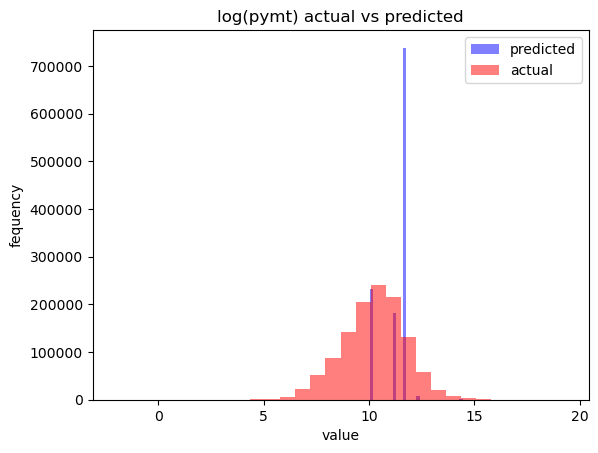

In [131]:
plt.hist(np.log(y_pred.apply(lambda x:x if x!=0 else 1)), bins=30, alpha=0.5, color="blue", label="predicted")
plt.hist(np.log(actual_y.apply(lambda x:x if x!=0 else 1)), bins=30, alpha=0.5, color='red',label='actual')

plt.legend()
plt.xlabel('value')
plt.ylabel('fequency')
plt.title('log(pymt) actual vs predicted')
plt.show()

For individual data points, the model fails miserablly. But if we only care about the total pymt amount, it performs pretty good.